In [1]:
#Import standard packages
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from scipy import io
from scipy import stats
import pickle
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from dlab import analysis_pipeline as analysis
from scipy import signal
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
import random
from pykalman import KalmanFilter
from dlab.continuous_traces import gaussian_filter1d

# If you would prefer to load the '.h5' example file rather than the '.pickle' example file. You need the deepdish package
# import deepdish as dd 

#Import metrics
from Neural_Decoding.metrics import get_R2
from Neural_Decoding.metrics import get_rho

#Import decoder functions
from Neural_Decoding.decoders import KalmanFilterDecoder

ModuleNotFoundError: No module named 'h5py'

In [ ]:
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import random

def get_random_n(lst, n):
  """Gets n random elements from a list."""
  if n > len(lst):
    return "n cannot be greater than the length of the list."

  return random.sample(lst, n)

def upsample_kinematics(x,y,sample_num = 30):
    # Generate corresponding index points for the original array
    x_original = np.linspace(0, len(x) - 1, len(x))
    y_original = np.linspace(0, len(y) - 1, len(x))

    # Create the interpolation function
    interp_funcx = interp1d(x_original, x, kind='cubic')  # You can change 'linear' to 'cubic' for cubic interpolation
    interp_funcy = interp1d(y_original, y, kind='cubic')
    # Generate 100 points for interpolation
    x_new = np.linspace(0, len(x) - 1, sample_num)
    y_new = np.linspace(0, len(y) - 1, sample_num)

    # Get the interpolated values
    axis_newx = interp_funcx(x_new)
    axis_newy = interp_funcy(y_new)

    return axis_newx,axis_newy

In [6]:
folder = r'C:\Users\Kim\Documents\Data'

with open(folder+'\example_data_s1.pickle','rb') as f:
#     neural_data,vels_binned=pickle.load(f,encoding='latin1') #If using python 3
    neural_data,vels_binned=pickle.load(f)
    
# #If you would prefer to load the '.h5' example file rather than the '.pickle' example file.
# data=dd.io.load(folder+'example_data_s1.h5')
# neural_data=data['neural_data']
# vels_binned=data['vels_binned']

In [7]:
np.shape(neural_data)

(61339, 52)

In [11]:
#For the Kalman filter, we use the position, velocity, and acceleration as outputs
#Ultimately, we are only concerned with the goodness of fit of velocity (for this dataset)
#But using them all as covariates helps performance

#We will now determine position
pos_binned=np.zeros(vels_binned.shape) #Initialize 
pos_binned[0,:]=0 #Assume starting position is at [0,0]
#Loop through time bins and determine positions based on the velocities
for i in range(pos_binned.shape[0]-1): 
    pos_binned[i+1,0]=pos_binned[i,0]+vels_binned[i,0]*.05 #Note that .05 is the length of the time bin
    pos_binned[i+1,1]=pos_binned[i,1]+vels_binned[i,1]*.05

#We will now determine acceleration    
temp=np.diff(vels_binned,axis=0) #The acceleration is the difference in velocities across time bins 
acc_binned=np.concatenate((temp,temp[-1:,:]),axis=0) #Assume acceleration at last time point is same as 2nd to last

#The final output covariates include position, velocity, and acceleration
y_kf=np.concatenate((pos_binned,vels_binned,acc_binned),axis=1)

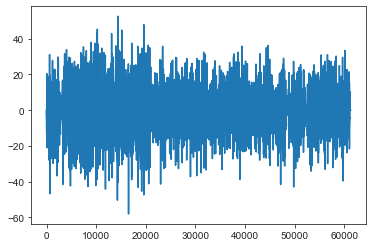

In [331]:
plt.plot(y_kf[:,2])

# load data

In [146]:
def moving_average_spiketrain(spiketrain, window_size):
    """Compute the moving average of a binary spike train.

    Args:
        spiketrain (np.ndarray): 1D array of 0s and 1s representing spike events.
        window_size (int): Number of samples to average over.

    Returns:
        np.ndarray: The smoothed spike train.
    """
    window = np.ones(window_size) / window_size
    return np.convolve(spiketrain, window, mode='same')

In [364]:
#df_load = pd.read_json(r'C:\Users\Kim\Documents\Data\PAPERFIGURES2024\MoveMod\zeta2_final\df_zeta2.json')
#df_ = df_load[df_load.group=='good']
#df_reaches = pd.read_json(r'C:\Users\Kim\Documents\Data\final\df_reaches7.json')
#df_kinematics_master = pd.read_json(r'C:\Users\Kim\Documents\Data\kinematics\TrainRecord\df_kinematics_master.json')
df_kinematics = df_kinematics_master[df_kinematics_master.preprocess=='raw'][df_kinematics_master.phase=='recording'][df_kinematics_master.cohort!='cntrl24D'][df_kinematics_master.cohort!='cup24D']

#df_kinematics['mouse'] = df_kinematics['mouse'].map(lambda x: x.lstrip('GN')) # remove GN from mouse ID labels
#df_kinematics['mouse'] = df_kinematics['mouse'].map(lambda x: x.lstrip('0'))
#df_kinematics[['mouse']] = df_kinematics[['mouse']].astype(int) # make all a string as some are integers and some are strings 

C:\Users\Kim\AppData\Local\Temp/ipykernel_50192/487187046.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_kinematics = df_kinematics_master[df_kinematics_master.preprocess=='raw'][df_kinematics_master.phase=='recording'][df_kinematics_master.cohort!='cntrl24D'][df_kinematics_master.cohort!='cup24D']


In [20]:
df_reaches.drop(['level_0'],axis=1,inplace=True)

C:\Users\Kim\AppData\Local\Temp/ipykernel_50192/468012195.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df = df_[df_.mouse==97][df_.zetaRate>5]


In [824]:
def GetData(df,df_k,bin_size = 0.001,window_size = 20,smooth=1):
    
    dt = 1/150

    trial_concat = []
    smooth_concat = []
    resampled_xreaches = []
    resampled_yreaches = []
    resampled_xvel = []
    resampled_yvel = []
    resampled_xacc = []
    resampled_yacc = []

    for i,m_ind in enumerate(df_k.max_ind):

        start_index = df_k.StartIndex[i]
        begin_frames = df_k.toMax[i]
        end_frames = df_k.toEnd[i]
        begin = m_ind 
        end = end_frames - m_ind
        pre = begin * (1/150) # 150 is frame rate
        post = end * (1/150)

        unit_trials = []
        smooth_trials = []
        for spike_times in df.times:
            spike_times = np.array(spike_times)
            event_times = df_r[df_r.reachInit==start_index].rMax_t
            event_times = list(event_times)
            psth, var, edges, trials = analysis.trial_by_trial(spike_times, event_times, pre=pre, post=post, bin_size=bin_size)
            unit_trials.append(trials[0])
            sm_trial = moving_average_spiketrain(trials[0], window_size=window_size)
            smooth_trials.append(np.sqrt(sm_trial))
            #smooth_trials.append(gaussian_filter1d(trials[0],sigma=1))

        trial_concat.append(unit_trials)
        smooth_concat.append(smooth_trials)

        x_raw = gaussian_filter1d(df_k.xpos_toEnd[i],smooth)
        y_raw = gaussian_filter1d(df_k.ypos_toEnd[i],smooth)
        #x_ = x_raw
        #y_ = y_raw
        x_ = np.array(x_raw) / x_raw[0]
        y_ = np.array(y_raw) / y_raw[0]


        vel_x = np.gradient(x_raw, dt)
        vel_y = np.gradient(y_raw, dt)
        #vel_x = np.array(vel_x) / vel_x[0]
        #vel_y = np.array(vel_y) / vel_y[0]
        acc_x = np.gradient(vel_x, dt)
        acc_y = np.gradient(vel_y, dt)
        #acc_x = np.array(acc_x) / acc_x[0]
        #acc_y = np.array(acc_y) / acc_y[0]


        x_resamp,y_resamp = upsample_kinematics(x_,y_,sample_num = np.shape(sm_trial)[0])
        resampled_xreaches.extend(x_resamp)
        resampled_yreaches.extend(y_resamp)

        velx_resamp,vely_resamp = upsample_kinematics(vel_x,vel_y,sample_num = np.shape(sm_trial)[0])
        resampled_xvel.extend(velx_resamp)
        resampled_yvel.extend(vely_resamp)

        accx_resamp,accy_resamp = upsample_kinematics(acc_x,acc_y,sample_num = np.shape(sm_trial)[0])
        resampled_xacc.extend(accx_resamp)
        resampled_yacc.extend(accy_resamp)

        mouse_neural = np.hstack(trial_concat).T
        mouse_neuralSmooth = np.hstack(smooth_concat).T

        kinematics = np.array([resampled_xreaches,resampled_yreaches,resampled_xvel,resampled_yvel,resampled_xacc,resampled_yacc]).T
    return mouse_neuralSmooth,kinematics


In [540]:
def GetData_reachMax(df,df_k,window_size = 20):
    
    bin_size = 0.005
    dt = 1/150

    trial_concat = []
    smooth_concat = []
    resampled_xreaches = []
    resampled_yreaches = []
    resampled_xvel = []
    resampled_yvel = []
    resampled_xacc = []
    resampled_yacc = []

    for i,m_ind in enumerate(df_k.max_ind):

        start_index = df_k.StartIndex[i]
        begin_frames = df_k.toMax[i]
        #end_frames = df_k.toEnd[i]
        begin = m_ind 
        end = end_frames - m_ind
        pre = begin * (1/150) # 150 is frame rate
        #post = end * (1/150)
        post = 0

        unit_trials = []
        smooth_trials = []
        for spike_times in df.times:
            spike_times = np.array(spike_times)
            event_times = df_r[df_r.reachInit==start_index].rMax_t
            event_times = list(event_times)
            psth, var, edges, trials = analysis.trial_by_trial(spike_times, event_times, pre=pre, post=post, bin_size=bin_size)
            unit_trials.append(trials[0])
            smooth_trials.append(moving_average_spiketrain(trials[0], window_size=window_size))
            #smooth_trials.append(gaussian_filter1d(trials[0],sigma=1))

        trial_concat.append(unit_trials)
        smooth_concat.append(smooth_trials)

        x_raw = df_k.xpos_toMax[i]
        y_raw = df_k.ypos_toMax[i]
        x_ = np.array(x_raw) / x_raw[0]
        y_ = np.array(y_raw) / y_raw[0]

        vel_x = np.gradient(x_raw, dt)
        vel_y = np.gradient(y_raw, dt)
        acc_x = np.gradient(vel_x, dt)
        acc_y = np.gradient(vel_y, dt)


        x_resamp,y_resamp = upsample_kinematics(x_,y_,sample_num = np.shape(trials)[1])
        resampled_xreaches.extend(x_resamp)
        resampled_yreaches.extend(y_resamp)

        velx_resamp,vely_resamp = upsample_kinematics(vel_x,vel_y,sample_num = np.shape(trials)[1])
        resampled_xvel.extend(velx_resamp)
        resampled_yvel.extend(vely_resamp)

        accx_resamp,accy_resamp = upsample_kinematics(acc_x,acc_y,sample_num = np.shape(trials)[1])
        resampled_xacc.extend(accx_resamp)
        resampled_yacc.extend(accy_resamp)

        mouse_neural = np.hstack(trial_concat).T
        mouse_neuralSmooth = np.hstack(smooth_concat).T

        kinematics = np.array([resampled_xreaches,resampled_yreaches,resampled_xvel,resampled_yvel,resampled_xacc,resampled_yacc]).T
    return mouse_neuralSmooth,kinematics


In [541]:
#X_kf_train,y_kf_train = GetData_reachMax(df,df_k[:70])
#X_kf_test,y_kf_test = GetData_reachMax(df,df_k[71:75].reset_index())
#X_kf_valid,y_kf_valid = GetData_reachMax(df,df_k[76:].reset_index())

In [597]:
import seaborn as sns

In [618]:
df_k = df_k[df_k.duration<0.2]
df_k.reset_index(inplace=True)
df_k.drop(['level_0'],axis=1,inplace=True)

In [761]:
df_.mouse.unique()

array([  97,  100,  101,   99,  103,   96,  102, 5481, 5454, 5480,  271,
        273,  276,  274,  275, 5475, 5473,  170,  161,  167,  159,  164,
        166,  168,  203,   65,   67,   68,   71, 5477,   49,   53,   56,
         58,   66,   69,   59], dtype=int64)

In [812]:
mid = 97

In [825]:
df = df_[df_.mouse==mid][df_.zetaRate>3]
df_r = df_reaches[df_reaches.mouse==mid].reset_index()
df_k = df_kinematics[df_kinematics.mouse==mid].reset_index()

C:\Users\Kim\AppData\Local\Temp/ipykernel_50192/1406877213.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df = df_[df_.mouse==mid][df_.zetaRate>3]


In [826]:
#take 10% of reaches
num_reaches_to_test = int(np.shape(df_k)[0]*0.10)
test_list = get_random_n(list(df_k.index.values),num_reaches_to_test)

df_k_train = df_k.drop(test_list)
df_k_train.reset_index(drop=True, inplace=True)
df_k_test = df_k.iloc[test_list]
df_k_test.reset_index(drop=True, inplace=True)

In [827]:
X_kf_train,y_kf_train = GetData(df,df_k_train,bin_size=0.005,window_size=20,smooth=2)
#X_kf_test,y_kf_test = GetData(df,df_k[66:73].reset_index(),bin_size=0.001,window_size=25,smooth=1)
X_kf_valid,y_kf_valid = GetData(df,df_k_test.reset_index(),bin_size = 0.005,window_size=20,smooth=2)

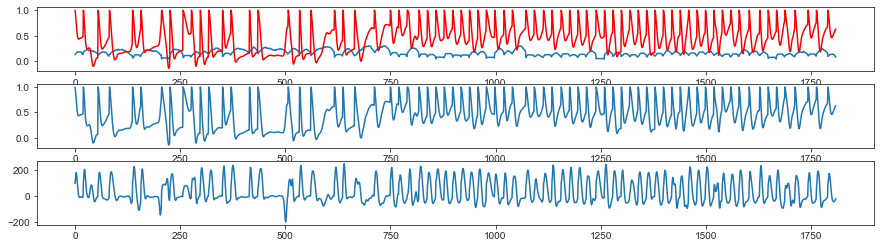

In [828]:
fig,(ax1,ax2,ax3) = plt.subplots(3,figsize=(15, 4))
ax1.plot(np.mean(X_kf_train,axis=1))
ax1.plot(y_kf_train[:,0],c='red')
ax2.plot(y_kf_train[:,0])
ax3.plot(y_kf_train[:,2])

In [817]:
#matrix = X_kf_valid.T
#rows_to_remove = [52]
#X_kf_valid = [row for i, row in enumerate(matrix) if i not in rows_to_remove]

In [818]:
#X_kf_train = np.array(X_kf_train).T
#X_kf_test = np.array(X_kf_test).T
#_kf_valid = np.array(X_kf_valid).T

In [829]:
#Z-score inputs 
X_kf_train_mean=np.nanmean(X_kf_train,axis=0)
X_kf_train_std=np.nanstd(X_kf_train,axis=0)
X_kf_train=(X_kf_train-X_kf_train_mean)/X_kf_train_std
#X_kf_test=(X_kf_test-X_kf_train_mean)/X_kf_train_std
X_kf_valid=(X_kf_valid-X_kf_train_mean)/X_kf_train_std

#Zero-center outputs
y_kf_train_mean=np.mean(y_kf_train,axis=0)
y_kf_train=y_kf_train-y_kf_train_mean
#y_kf_test=y_kf_test-y_kf_train_mean
y_kf_valid=y_kf_valid-y_kf_train_mean

In [830]:
#Declare model
model_kf=KalmanFilterDecoder(C=1) #There is one optional parameter that is set to the default in this example (see ReadMe)

#Fit model
model_kf.fit(np.array(X_kf_train),np.array(y_kf_train))

#Get predictions
y_valid_predicted_kf=model_kf.predict(np.array(X_kf_valid),np.array(y_kf_valid))

#Get metrics of fit (see read me for more details on the differences between metrics)
#First I'll get the R^2
R2_kf=get_R2(np.array(y_kf_valid),np.array(y_valid_predicted_kf))
print('R2:',R2_kf[0:2]) #I'm just printing the R^2's of the 3rd and 4th entries that correspond to the velocities
#Next I'll get the rho^2 (the pearson correlation squared)
rho_kf=get_rho(np.array(y_kf_valid),np.array(y_valid_predicted_kf))
print('rho2:',rho_kf[0:1]**2) #I'm just printing the rho^2's of the 3rd and 4th entries that correspond to the velocities

R2: [   0.34421954 -215.93238994]
rho2: [0.42380543]


R2: [   0.34421954 -215.93238994]
rho2: [0.42380543]


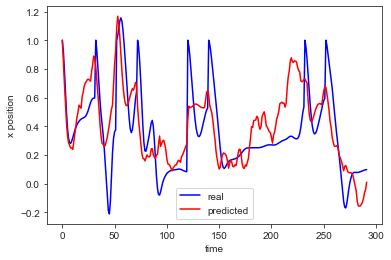

In [831]:

#As an example, I plot an example 1000 values of the x velocity (column index 2), both true and predicted with the Kalman filter
#Note that I add back in the mean value, so that both true and predicted values are in the original coordinates
fig_x_kf=plt.figure()

plt.plot(y_kf_valid[:,0]+y_kf_train_mean[0],'b',label='real')
plt.plot(y_valid_predicted_kf[:,0]+y_kf_train_mean[0],'r',label='predicted')
plt.xlabel('time')
plt.ylabel('x position')
plt.legend()

R2_kf=get_R2(np.array(y_kf_valid),np.array(y_valid_predicted_kf))
print('R2:',R2_kf[0:2]) #I'm just printing the R^2's of the 3rd and 4th entries that correspond to the velocities
#Next I'll get the rho^2 (the pearson correlation squared)
rho_kf=get_rho(np.array(y_kf_valid),np.array(y_valid_predicted_kf))
print('rho2:',rho_kf[0:1]**2)
#Save figure
# fig_x_kf.savefig('x_velocity_decoding.eps')

R2: [   0.34421954 -215.93238994]
rho2: [0.42380543]


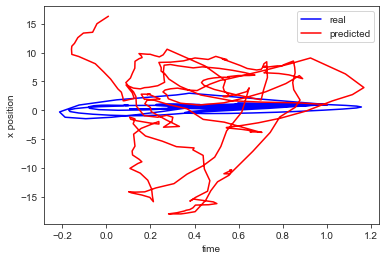

In [832]:
fig_x_kf=plt.figure()

plt.plot(y_kf_valid[:,0]+y_kf_train_mean[0],y_kf_valid[:,1]+y_kf_train_mean[1],'b',label='real')
plt.plot(y_valid_predicted_kf[:,0]+y_kf_train_mean[0],y_valid_predicted_kf[:,1]+y_kf_train_mean[1],'r',label='predicted')
plt.xlabel('time')
plt.ylabel('x position')
plt.legend()

R2_kf=get_R2(np.array(y_kf_valid),np.array(y_valid_predicted_kf))
print('R2:',R2_kf[0:2]) #I'm just printing the R^2's of the 3rd and 4th entries that correspond to the velocities
#Next I'll get the rho^2 (the pearson correlation squared)
rho_kf=get_rho(np.array(y_kf_valid),np.array(y_valid_predicted_kf))
print('rho2:',rho_kf[0:1]**2)

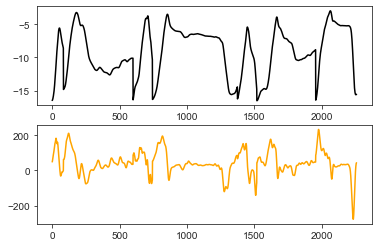

In [614]:
fig,((ax1,ax2)) = plt.subplots(2)
ax1.plot(y_kf_valid[:,0]+y_kf_train_mean[0],'black')
ax2.plot(y_kf_valid[:,2]+y_kf_train_mean[2],'orange')

In [677]:
df_.mouse.unique()

array([  97,  100,  101,   99,  103,   96,  102, 5481, 5454, 5480,  271,
        273,  276,  274,  275, 5475, 5473,  170,  161,  167,  159,  164,
        166,  168,  203,   65,   67,   68,   71, 5477,   49,   53,   56,
         58,   66,   69,   59], dtype=int64)

In [681]:
df_t = df_[df_.timepoint==2][df_.mouse!=59]

C:\Users\Kim\AppData\Local\Temp/ipykernel_50192/2206018319.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_t = df_[df_.timepoint==2][df_.mouse!=59]


In [682]:
df_t.mouse.unique()

array([  97,  100,  101,   99,  103,   96,  102, 5481, 5454, 5480,  271,
        273,  276,  274,  275,   49,   53,   56,   58,   66,   69],
      dtype=int64)

In [683]:
df_t.columns

Index(['group', 'times', 'template', 'waveform_weights', 'xpos', 'ypos',
       'experiment', 'probe', 'cell', 'waveform', 'mouse', 'cohort',
       'timepoint', 'overall_rate', 'waveform_duration', 'waveform_PTratio',
       'waveform_repolarizationslope', 'waveform_class', 'depth', 'layer',
       'surface_depth', 'surface_channel', 'cohort2', 'aligned', 'index',
       'mod_up', 'mod_down', 'pval', 'modulated', 'peakup', 'peakdown',
       'maxfr', 'minfr', 'baselineFR', 'epochFR', 'presence_ratio',
       'amplitude', 'reliability', 'amps', 'log_epochFR', 'logFR', 'new_times',
       'zeta', 'peakValue', 'peakWidth', 'peakLatency', 'peakOnset',
       'zetaRate', 'vecRate', 'binz'],
      dtype='object')

In [687]:
df_thomas = df_t[['mouse','cohort','times','waveform_class']]

In [700]:
df_r = df_reaches[df_reaches.timepoint!=3]

In [701]:
df_r.columns

Index(['reachInit', 'reachMax', 'reachEnd', 'stim', 'end_category',
       'behaviors', 'mouse', 'cohort', 'rMax_t', 'timepoint', 'index'],
      dtype='object')

In [702]:
df_r = df_r[['mouse','cohort','rMax_t']]

In [703]:
df_r.mouse.unique()

array([  49,   53,   56,   58,   59,   66,   69,  100,  101,  102,  103,
        104,  203, 5454, 5478, 5480, 5481,   96,   97,   99,  599,  600,
        566,  544,  273,  275,  276,  274,  271], dtype=int64)

In [711]:
df_r = df_r[df_r.mouse!=104][df_r.mouse!=203][df_r.mouse!=599][df_r.mouse!=600][df_r.mouse!=566][df_r.mouse!=544][df_r.mouse!=59][df_r.mouse!=5478]

C:\Users\Kim\AppData\Local\Temp/ipykernel_50192/3314276263.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_r = df_r[df_r.mouse!=104][df_r.mouse!=203][df_r.mouse!=599][df_r.mouse!=600][df_r.mouse!=566][df_r.mouse!=544][df_r.mouse!=59][df_r.mouse!=5478]
